# Tutorial of py-ship-simulator

### はじめに
`py-ship-simulator`では，大きく分けてship model (maneuvering model and hull shape), actuator model, wind model, world modelがシミュレーション可能です．これらのモデルを組み合わせることで以下のような様々なシミュレーションを実行可能です．
- ship model : 時事刻々の制御状態と真風速風向を設定可能な操縦シミュレーション
- ship model + world model : 時事刻々の制御状態と真風速風向を設定可能な衝突判定を含めた操縦シミュレーション
- ship model + actuator model : 時事刻々の制御入力と真風速風向を設定可能な操縦シミュレーション
- ship model + wind model : 時事刻々の制御入力を設定可能な風況の影響を考慮した操縦シミュレーション

実装されているシミュレートオブジェクトを以下にまとめる．

- ship model
  - `MMGEssoOsaka3m`, `MMGEssoOsaka3mWithThruster`
  - `MMGTakaoki3m`
- actuator model
  - `Propeller`
  - `Rudder`
  - `VecTwinRudder`
  - `BowThruster`
  - `SternThruster`
- actuator command model
  - `PropellerConstantCommander`, `PropellerUniformCommander`, `PropellerNormalCommander`
  - `RudderConstantCommander`, `RudderUniformCommander`, `RudderNormalCommander`
  - `VecTwinRudderConstantCommander`, `VecTwinRudderUniformCommander`, `VecTwinRudderNormalCommander`
  - `BowThrusterConstantCommander`, `BowThrusterUniformCommander`, `BowThrusterUniformCommander`
  - `SternThrusterConstantCommander`, `SternThrusterUniformCommander`, `SternThrusterUniformCommander`
- reference model
  - `ReferenceFilter`
  - `ReferencePoseTrajectory`
  - `FourCornerReferencePoseTrajectory`
- wind model
  - `StationaryWind`
  - `RandomWind`
- world model
  - `InukaiPond`
  - `Ariake`
  - `Nanko`
  - `CornerBerth`
  - `StraightBerth`


### Import library

In [1]:
import warnings
import numpy as np

import pyshipsim
from utils import font_setting

warnings.simplefilter('ignore')
font_setting()

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
ImportError: Import of pcc_3m's f2py module failed.
ImportError: Import of flap3rd's f2py module failed.


## 時事刻々の制御状態と真風速風向を設定可能な操縦シミュレーション (ship model)

------------------ Simulator Info ------------------
Given objects:
    MMGEssoOsaka3m:
        State variables
            x_position_mid [m]: [-inf, inf]
            u_velo [m/s]: [-inf, inf]
            y_position_mid [m]: [-inf, inf]
            vm_velo [m/s]: [-inf, inf]
            psi [rad]: [-inf, inf]
            r_angvelo [rad/s]: [-inf, inf]
        External State variables
            delta_rudder [rad]: [-0.6108652381980153, 0.6108652381980153]
            n_prop [rps]: [-20, 20]
            true_wind_speed [m/s]: [0.0, inf]
            true_wind_direction [rad]: [0.0, 6.283185307179586]
        Observation variables
            hat_x_position_mid [m]: [-inf, inf]
            hat_u_velo [m/s]: [-inf, inf]
            hat_y_position_mid [m]: [-inf, inf]
            hat_vm_velo [m/s]: [-inf, inf]
            hat_psi [rad]: [-inf, inf]
            hat_r_angvelo [rad/s]: [-inf, inf]
The state variables that need to be given are as follows:
    delta_rudder [rad]
    n_prop [rp

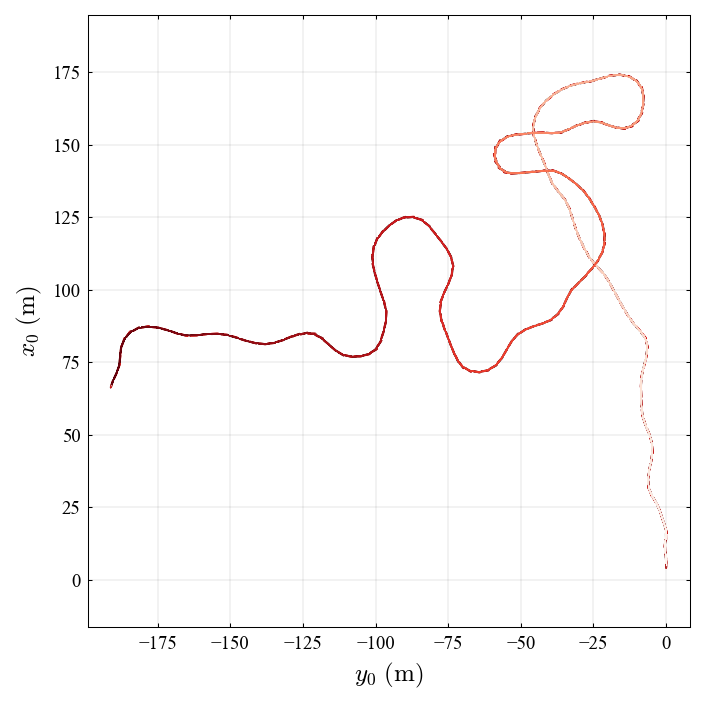

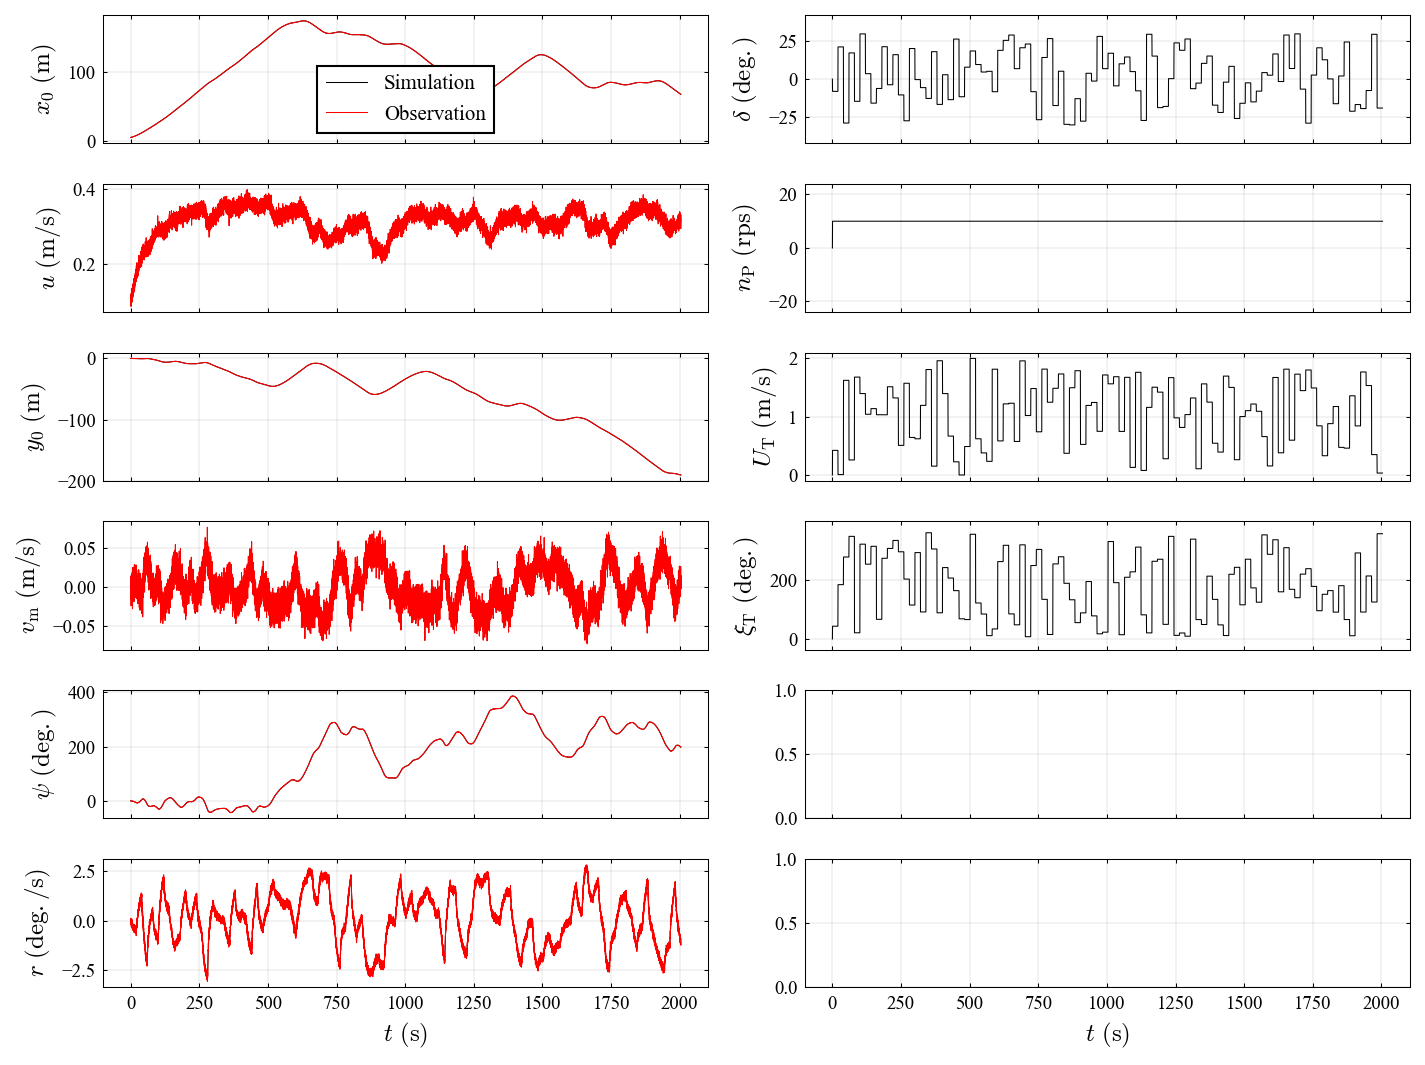

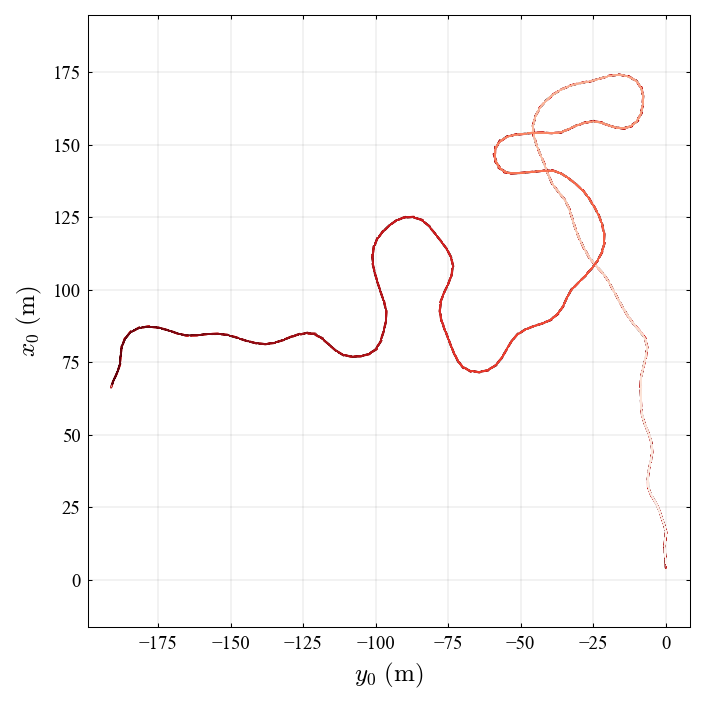

In [2]:
# 使用するシミュレーションオブジェクトを生成
esso = pyshipsim.MMGEssoOsaka3m(
    solve_method="euler",  # ode solverを指定
    interp_method="linear",  # 補間法を指定
    polygon_type="simple_ship",  # 衝突判定のための船型を指定
    f2py=True,  # f2pyを使うかどうか
)

# シミュレータを生成
sim = pyshipsim.Simulator(
    *[esso],  # シミュレーションに使用するオブジェクトを指定
    dt_act=20.0,  # 制御周期を指定
    dt_sim=0.1,  # シミュレーション周期を指定
)
sim.get_info()

# 乱数生成器を生成
np_random = np.random.Generator(np.random.PCG64(seed=1852))

# 与える制御状態と真風速風向を生成
N_T = 100  # 制御周期の回数を指定
delta_rudder = np_random.uniform(-np.deg2rad(30), np.deg2rad(30), size=(N_T))  # ランダムな舵角を生成
n_prop = np.array([10.0] * N_T)
true_wind_speed = np_random.uniform(0, 2, size=(N_T))  # ランダムな風速を生成
true_wind_direction = np_random.uniform(-np.deg2rad(180), np.deg2rad(180), size=(N_T))  # ランダムな風向を生成

# get_info()で確認したオブジェクト名の辞書データに初期状態変数を設定
x_position_mid, u_velo, y_position_mid, vm_velo, psi, r_angvelo = 5.0, 0.1, 0.0, 0.0, 0.0, 0.0
init_states = {
    "MMGEssoOsaka3m": [x_position_mid, u_velo, y_position_mid, vm_velo, psi, r_angvelo],
}

# get_info()で確認した制御入力の順番に制御入力を設定
action_seq = np.stack([delta_rudder, n_prop, true_wind_speed, true_wind_direction], axis=1)

# シミュレーションを実行
sim.reset(init_states, seed=np_random)
for i in range(N_T):
    _, terminated, _ = sim.step(action_seq[i])
    if terminated:
        break
sim.plot_x0y0(path="./log/tutorial_simulation/ship/")
sim.plot_timeseries(path="./log/tutorial_simulation/ship/")
sim.to_csv(path="./log/tutorial_simulation/ship/log.csv")

sim.plot_x0y0(path="./log/tutorial_simulation/ship/", ext="png")

## 時事刻々の制御状態と真風速風向を設定可能な衝突判定を含めた操縦シミュレーション ( + world model)


------------------ Simulator Info ------------------
Given objects:
    MMGEssoOsaka3m:
        State variables
            x_position_mid [m]: [-inf, inf]
            u_velo [m/s]: [-inf, inf]
            y_position_mid [m]: [-inf, inf]
            vm_velo [m/s]: [-inf, inf]
            psi [rad]: [-inf, inf]
            r_angvelo [rad/s]: [-inf, inf]
        External State variables
            delta_rudder [rad]: [-0.6108652381980153, 0.6108652381980153]
            n_prop [rps]: [-20, 20]
            true_wind_speed [m/s]: [0.0, inf]
            true_wind_direction [rad]: [0.0, 6.283185307179586]
        Observation variables
            hat_x_position_mid [m]: [-inf, inf]
            hat_u_velo [m/s]: [-inf, inf]
            hat_y_position_mid [m]: [-inf, inf]
            hat_vm_velo [m/s]: [-inf, inf]
            hat_psi [rad]: [-inf, inf]
            hat_r_angvelo [rad/s]: [-inf, inf]
    InukaiPond:
        State variables
        External State variables
        Observation va

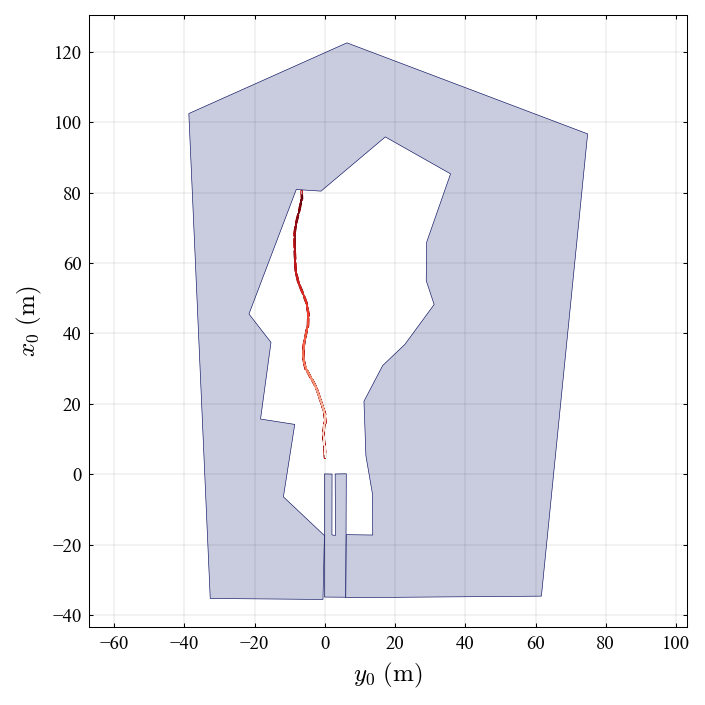

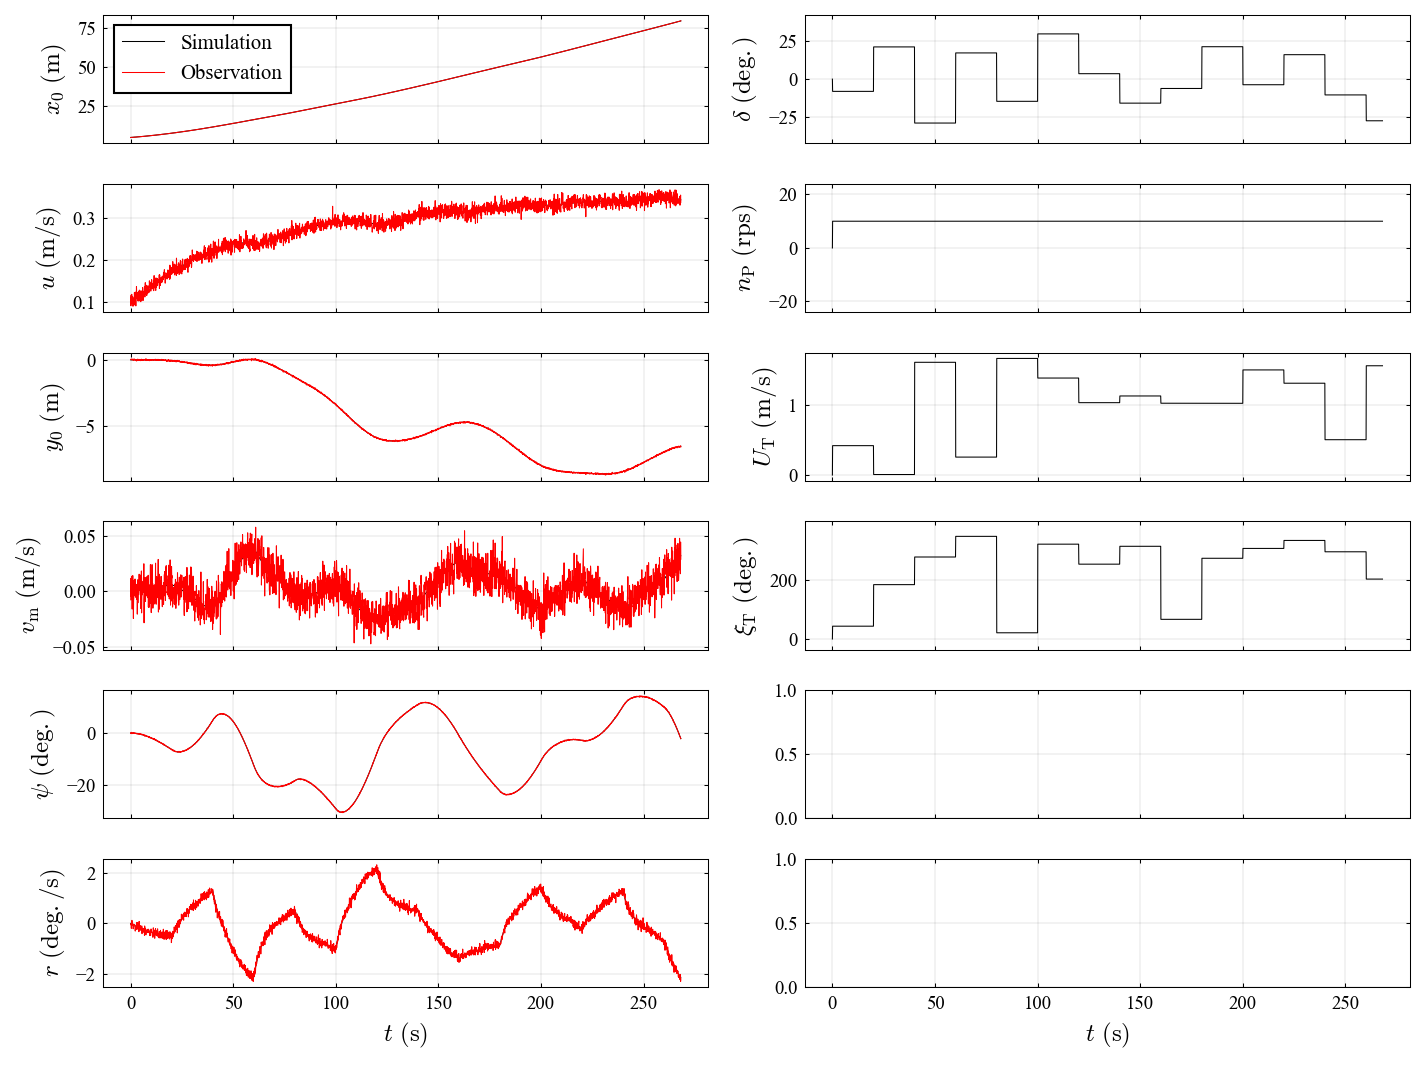

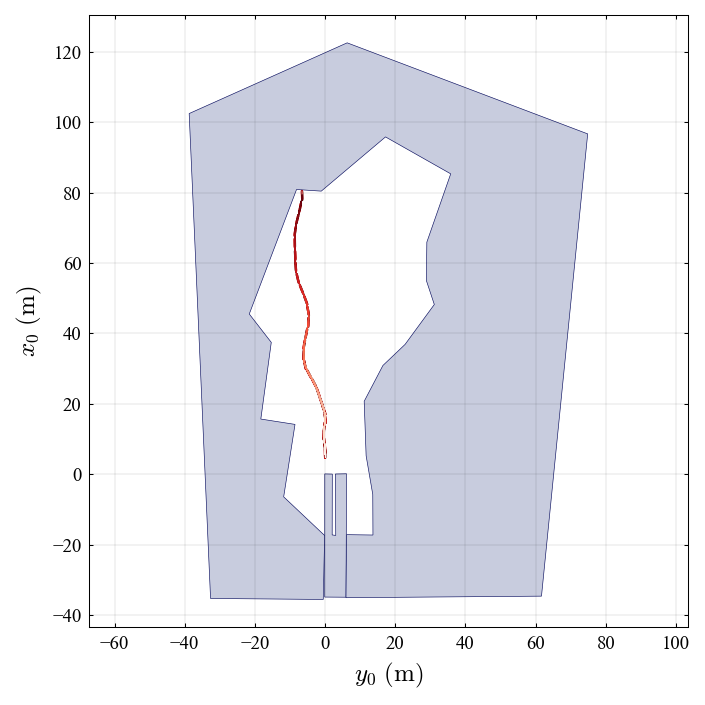

In [3]:
# 使用するシミュレーションオブジェクトを生成
world = pyshipsim.InukaiPond()  # シミュレーション領域を生成

# シミュレータを生成
sim = pyshipsim.Simulator(
    *[esso, world],  # worldを追加
    dt_act=20.0,
    dt_sim=0.1,
    collide_checker_type="strict",  # 衝突判定方法を指定
)
sim.get_info()

# 乱数生成器を生成
np_random = np.random.Generator(np.random.PCG64(seed=1852))

# 与える制御状態と真風速風向を生成
N_T = 100  # 制御周期の回数を指定
delta_rudder = np_random.uniform(-np.deg2rad(30), np.deg2rad(30), size=(N_T))  # ランダムな舵角を生成
n_prop = np.array([10.0] * N_T)
true_wind_speed = np_random.uniform(0, 2, size=(N_T))  # ランダムな風速を生成
true_wind_direction = np_random.uniform(-np.deg2rad(180), np.deg2rad(180), size=(N_T))  # ランダムな風向を生成

# get_info()で確認した状態の順番に初期状態を設定
x_position_mid, u_velo, y_position_mid, vm_velo, psi, r_angvelo = 5.0, 0.1, 0.0, 0.0, 0.0, 0.0
init_states = {
    "MMGEssoOsaka3m": [x_position_mid, u_velo, y_position_mid, vm_velo, psi, r_angvelo],
}
# get_info()で確認した制御入力の順番に制御入力を設定
action_seq = np.stack([delta_rudder, n_prop, true_wind_speed, true_wind_direction], axis=1)

# 同じ初期値と制御入力でシミュレーションを実行
sim.reset(init_states, seed=np_random)
for i in range(N_T):
    _, terminated, _ = sim.step(action_seq[i])
    if terminated:
        break
    
sim.plot_x0y0(path="./log/tutorial_simulation/ship_world/")
sim.plot_timeseries(path="./log/tutorial_simulation/ship_world/")
sim.to_csv(path="./log/tutorial_simulation/ship_world/log.csv")

sim.plot_x0y0(path="./log/tutorial_simulation/ship_world/", ext="png")

## 時事刻々の制御入力と真風速風向を設定可能な操縦シミュレーション ( + actuator model)
アクチュエータの応答モデルを考慮されます．

------------------ Simulator Info ------------------
Given objects:
    MMGEssoOsaka3m:
        State variables
            x_position_mid [m]: [-inf, inf]
            u_velo [m/s]: [-inf, inf]
            y_position_mid [m]: [-inf, inf]
            vm_velo [m/s]: [-inf, inf]
            psi [rad]: [-inf, inf]
            r_angvelo [rad/s]: [-inf, inf]
        External State variables
            delta_rudder [rad]: [-0.6108652381980153, 0.6108652381980153]
            n_prop [rps]: [-20, 20]
            true_wind_speed [m/s]: [0.0, inf]
            true_wind_direction [rad]: [0.0, 6.283185307179586]
        Observation variables
            hat_x_position_mid [m]: [-inf, inf]
            hat_u_velo [m/s]: [-inf, inf]
            hat_y_position_mid [m]: [-inf, inf]
            hat_vm_velo [m/s]: [-inf, inf]
            hat_psi [rad]: [-inf, inf]
            hat_r_angvelo [rad/s]: [-inf, inf]
    InukaiPond:
        State variables
        External State variables
        Observation va

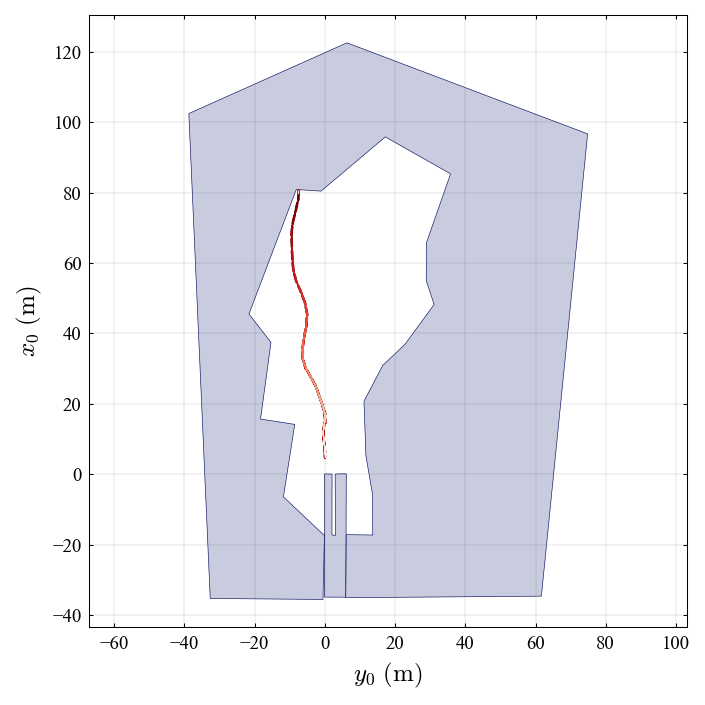

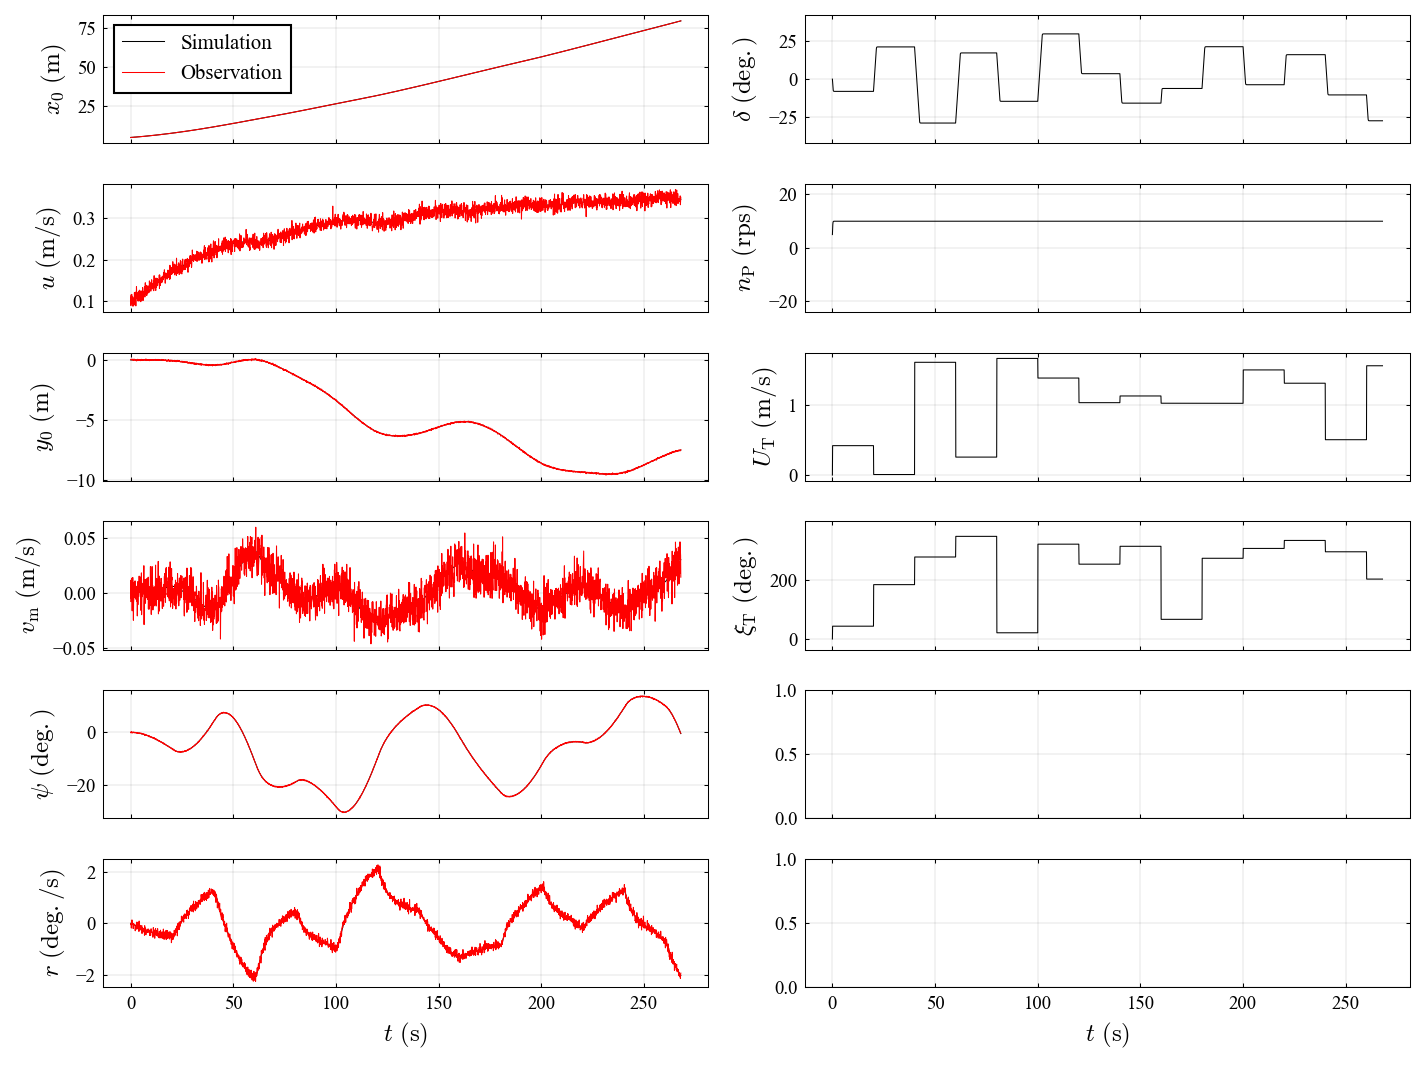

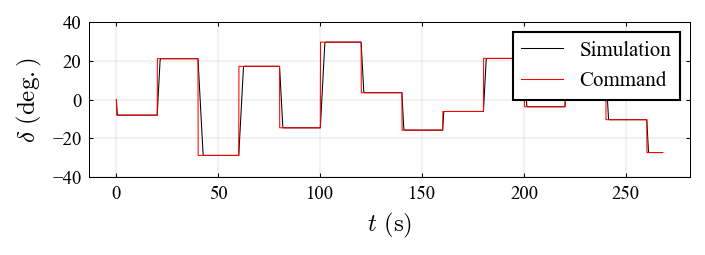

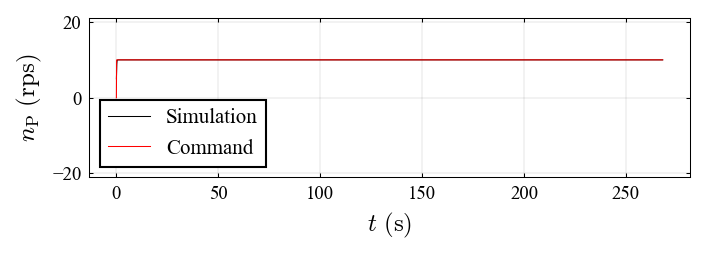

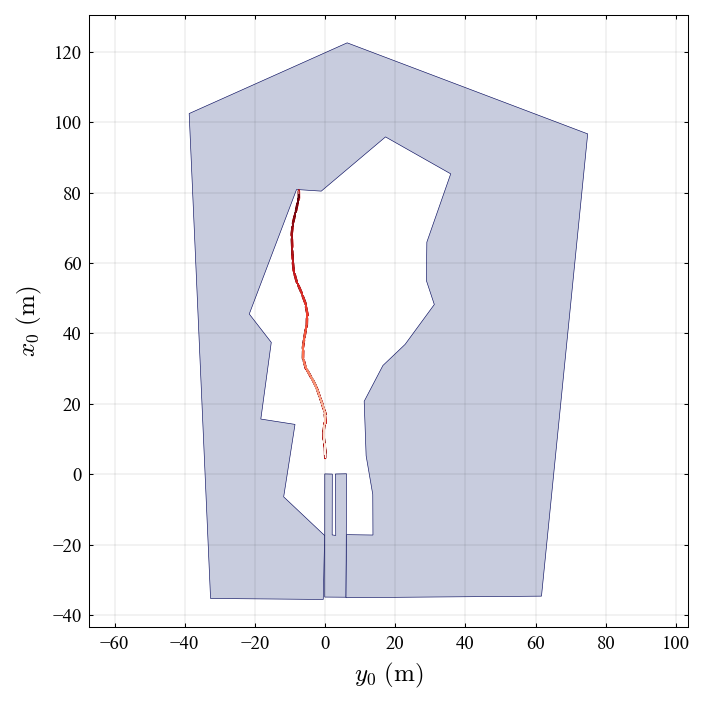

In [4]:
# 使用するシミュレーションオブジェクトを生成
prop = pyshipsim.Propeller()  # プロペラモデルを使用する
rud = pyshipsim.Rudder()  # 舵モデルを使用する

# シミュレータを生成
sim = pyshipsim.Simulator(
    *[esso, world, rud, prop],  # propとrudを追加
    dt_act=20.0,
    dt_sim=0.1,
    collide_checker_type="strict",
)
sim.get_info()

# 乱数生成器を生成
np_random = np.random.Generator(np.random.PCG64(seed=1852))

# 与える制御状態と真風速風向を生成
N_T = 100  # 制御周期の回数を指定
delta_rudder = np_random.uniform(-np.deg2rad(30), np.deg2rad(30), size=(N_T))  # ランダムな舵角を生成
n_prop = np.array([10.0] * N_T)
true_wind_speed = np_random.uniform(0, 2, size=(N_T))  # ランダムな風速を生成
true_wind_direction = np_random.uniform(-np.deg2rad(180), np.deg2rad(180), size=(N_T))  # ランダムな風向を生成

# get_info()で確認した状態の順番に初期状態を設定
x_position_mid, u_velo, y_position_mid, vm_velo, psi, r_angvelo = 5.0, 0.1, 0.0, 0.0, 0.0, 0.0
delta, n_p = 0.0, 5.0
init_states = {
    "MMGEssoOsaka3m": [x_position_mid, u_velo, y_position_mid, vm_velo, psi, r_angvelo],
    "Rudder": [delta],
    "Propeller": [n_p],
}
# get_info()で確認した制御入力の順番に制御入力を設定
action_seq = np.stack([true_wind_speed, true_wind_direction, delta_rudder, n_prop], axis=1)  # 制御周期分の入力を生成

# 同じ初期値と制御入力でシミュレーションを実行
sim.reset(init_states, seed=np_random)
for i in range(N_T):
    _, terminated, _ = sim.step(action_seq[i])
    if terminated:
        break
    
sim.plot_x0y0(path="./log/tutorial_simulation/ship_world_act/")
sim.plot_timeseries(path="./log/tutorial_simulation/ship_world_act/")
sim.to_csv(path="./log/tutorial_simulation/ship_world_act/log.csv")

sim.plot_x0y0(path="./log/tutorial_simulation/ship_world_act/", ext="png")

## 時事刻々の制御入力と設定可能な風況の影響を考慮した操縦シミュレーション ( + wind model)


------------------ Simulator Info ------------------
Given objects:
    MMGEssoOsaka3m:
        State variables
            x_position_mid [m]: [-inf, inf]
            u_velo [m/s]: [-inf, inf]
            y_position_mid [m]: [-inf, inf]
            vm_velo [m/s]: [-inf, inf]
            psi [rad]: [-inf, inf]
            r_angvelo [rad/s]: [-inf, inf]
        External State variables
            delta_rudder [rad]: [-0.6108652381980153, 0.6108652381980153]
            n_prop [rps]: [-20, 20]
            true_wind_speed [m/s]: [0.0, inf]
            true_wind_direction [rad]: [0.0, 6.283185307179586]
        Observation variables
            hat_x_position_mid [m]: [-inf, inf]
            hat_u_velo [m/s]: [-inf, inf]
            hat_y_position_mid [m]: [-inf, inf]
            hat_vm_velo [m/s]: [-inf, inf]
            hat_psi [rad]: [-inf, inf]
            hat_r_angvelo [rad/s]: [-inf, inf]
    InukaiPond:
        State variables
        External State variables
        Observation va

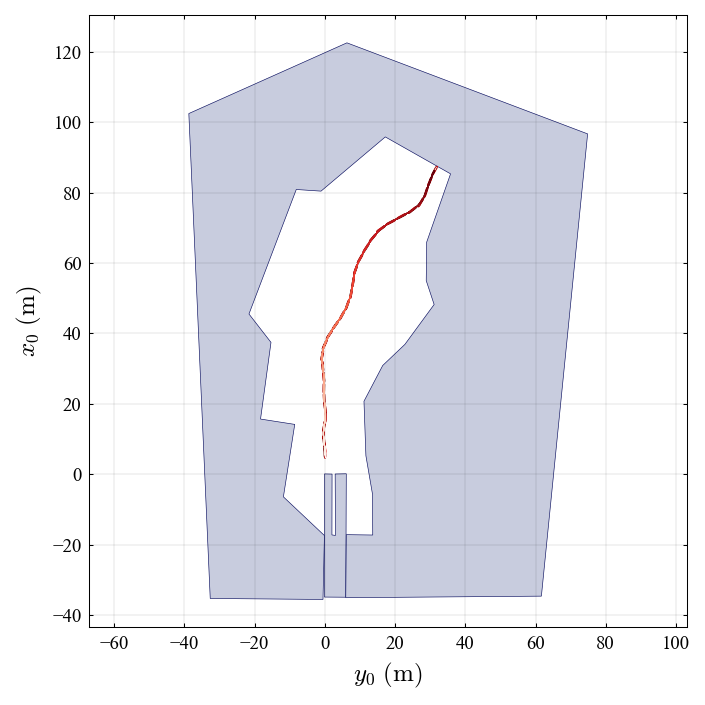

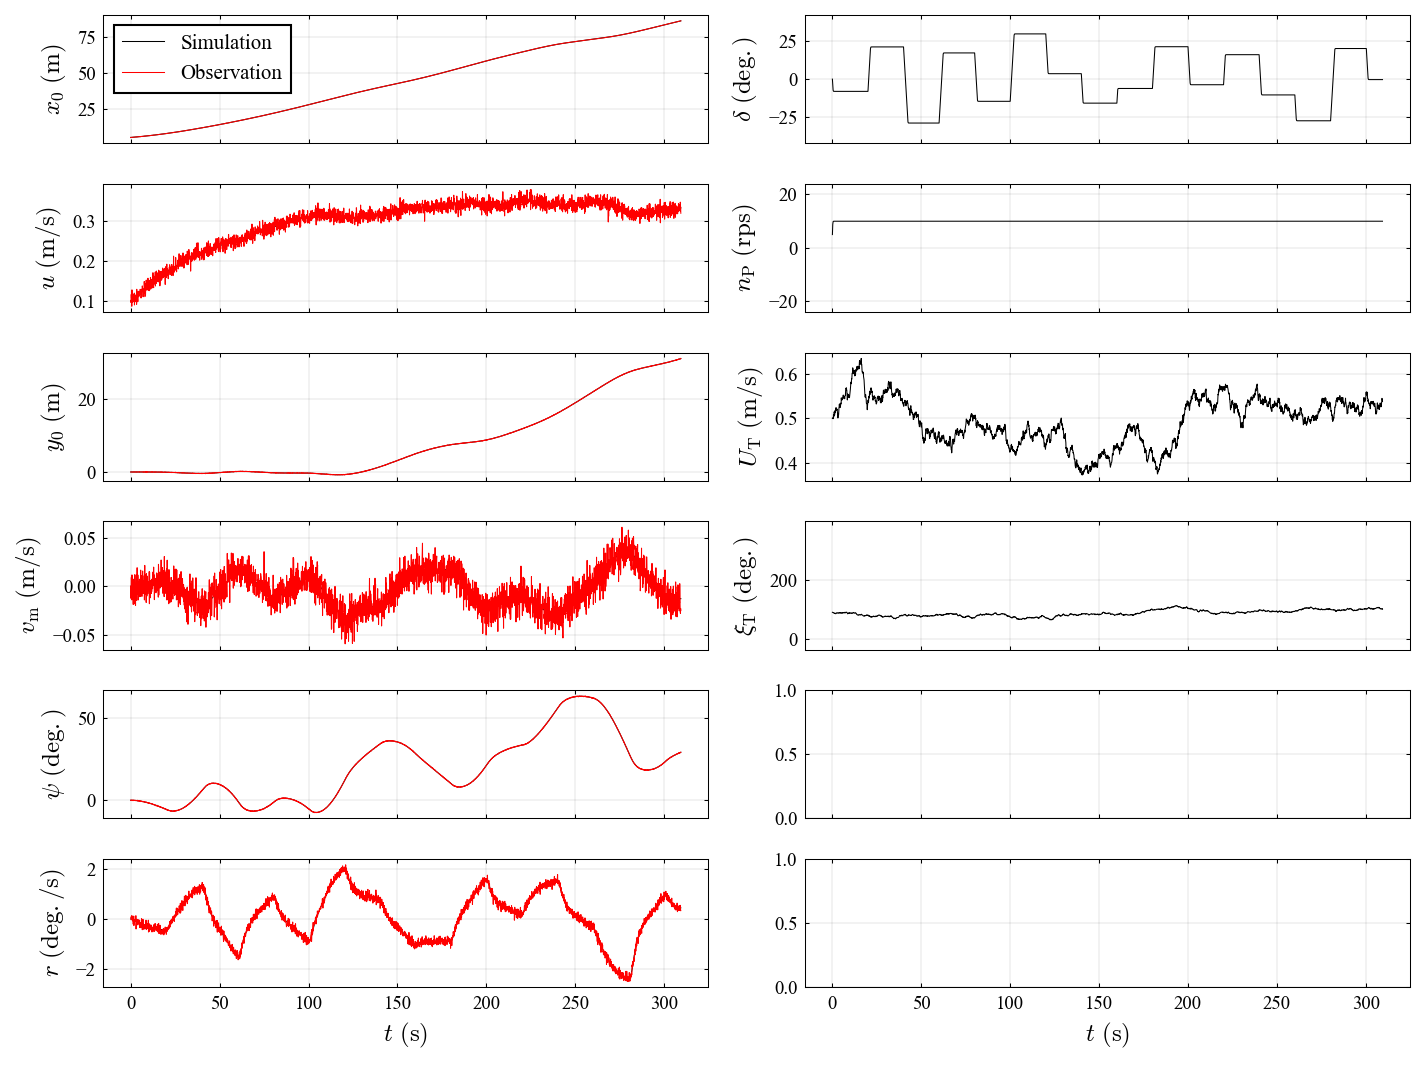

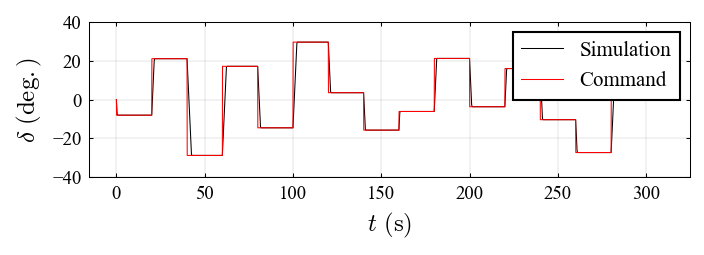

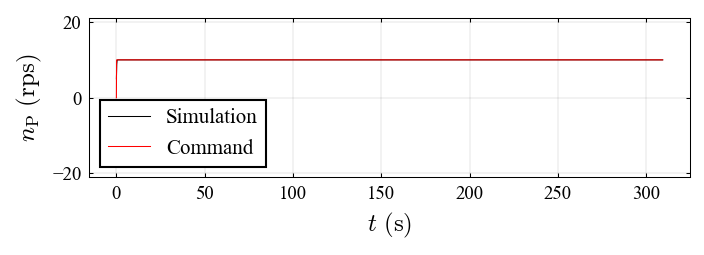

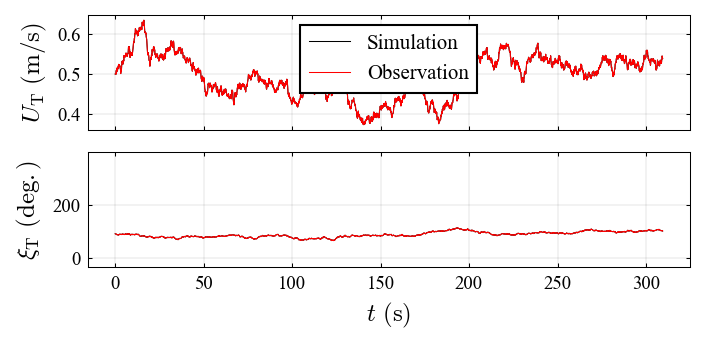

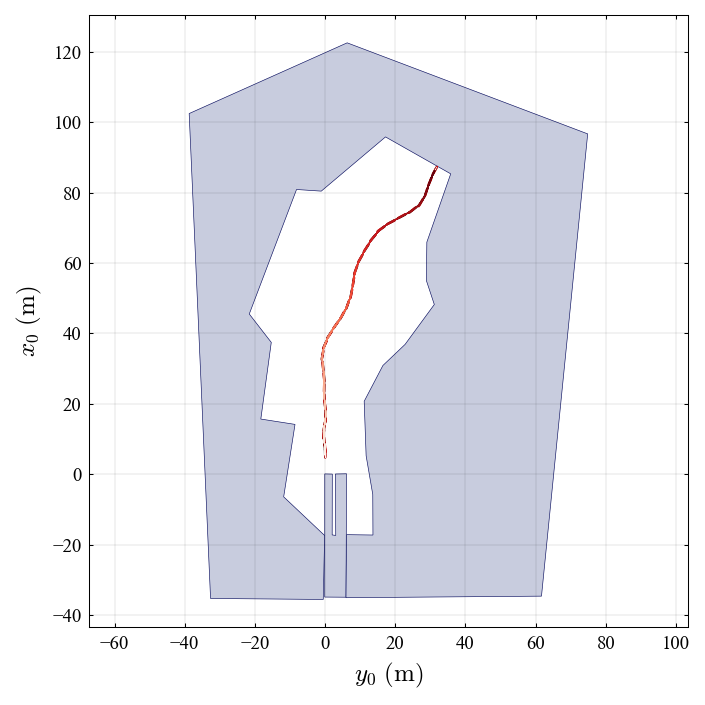

In [5]:
# 使用するシミュレーションオブジェクトを生成
wind = pyshipsim.RandomWind()  # 風のモデルを使用する

# シミュレータを生成
sim = pyshipsim.Simulator(
    *[esso, world, rud, prop, wind],  # windを追加
    dt_act=20.0,
    dt_sim=0.1,
    collide_checker_type="strict",
)
sim.get_info()

# 乱数生成器を生成
np_random = np.random.Generator(np.random.PCG64(seed=1852))

# 与える制御状態と真風速風向を生成
N_T = 100  # 制御周期の回数を指定
delta_rudder = np_random.uniform(-np.deg2rad(30), np.deg2rad(30), size=(N_T))  # ランダムな舵角を生成
n_prop = np.array([10.0] * N_T)

# get_info()で確認した状態の順番に初期状態を設定
x_position_mid, u_velo, y_position_mid, vm_velo, psi, r_angvelo = 5.0, 0.1, 0.0, 0.0, 0.0, 0.0
delta, n_p = 0.0, 5.0
true_wind_speed, true_wind_direction = 0.5, np.pi/2
init_states = {
    "MMGEssoOsaka3m": [x_position_mid, u_velo, y_position_mid, vm_velo, psi, r_angvelo],
    "Rudder": [delta],
    "Propeller": [n_p],
    "RandomWind": [true_wind_speed, true_wind_direction],
}
# get_info()で確認した制御入力の順番に制御入力を設定
action_seq = np.stack([delta_rudder, n_prop], axis=1)  # 制御周期分の入力を生成

# 同じ初期値と制御入力でシミュレーションを実行
sim.reset(init_states, seed=np_random)
for i in range(N_T):
    _, terminated, _ = sim.step(action_seq[i])
    if terminated:
        break

sim.plot_x0y0(path="./log/tutorial_simulation/ship_world_act_wind/")
sim.plot_timeseries(path="./log/tutorial_simulation/ship_world_act_wind/")
sim.to_csv(path="./log/tutorial_simulation/ship_world_act_wind/log.csv")

sim.plot_x0y0(path="./log/tutorial_simulation/ship_world_act_wind/", ext="png")